<a href="https://colab.research.google.com/github/a-sideffect/SC2001proj/blob/main/SC2001_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC2001 Project 1: Integration of Merge Sort & Insertion Sort

## Executive Summary
* **Objective:** Optimize standard Merge Sort by integrating Insertion Sort for small sub-array sizes ($\le S$) to eliminate recursive call overhead.
* **Key Metrics:** Total key comparisons and execution time (CPU time).

## 1. Algorithm Design & Implementation

### 1.1 Standard Merge Sort vs. Hybrid Sort
* **Merge Sort:** Recursive divide-and-conquer strategy down to single-element base cases.
* **Hybrid Algorithm:** Intercepts recursive splitting when array size drops to or below threshold $S$, switching directly to Insertion Sort.

### 1.2 Implementation Details
* **Language:** Python
* **Optimization:** In-place sub-array indexing using `low`, `mid`, and `high` boundaries to prevent memory allocation overhead.
* **Tracking:** Explicit comparison counter incremented on every element evaluation.

## 2. Theoretical Analysis

### 2.1 Standard Merge Sort
* **Time Complexity:** $\Theta(n \log n)$ key comparisons in worst, average, and best cases.

### 2.2 Hybrid Merge-Insertion Sort
* **Small Sub-array Sorting (Insertion Sort):** Sorting $n/S$ sub-arrays of size $S$ takes $\mathcal{O}(S^2)$ per block $\rightarrow \mathcal{O}(n S)$ total.
* **Merging Phase:** Merging $n/S$ sub-arrays takes $\mathcal{O}(n \log(n/S))$ key comparisons.
* **Overall Complexity:**
  $$\mathcal{O}\left(n S + n \log\left(\frac{n}{S}\right)\right)$$

## 3. Empirical Results & Analysis

### 3.1 Task (c)(i): Fixed $S$, Varying Input Size $n$
* **Dataset Sizes ($n$):** $1,000$ to $10,000,000$ random integers.
* **Observation:** Empirical comparison count matches theoretical $\mathcal{O}(n \log n)$ growth closely as $n$ scales.

### 3.2 Task (c)(ii): Fixed Input Size $n$, Varying $S$
* **Tested Range of $S$:** $[2, 5, 10, 20, 30, 50, 100, 200]$
* **Observation:** Key comparisons increase gradually as $S$ grows because Insertion Sort performs more comparisons ($\mathcal{O}(S^2)$) than Merge Sort ($\mathcal{O}(S \log S)$) on small lists.

### 3.3 Task (c)(iii): Determining Optimal $S$
* **Key Finding:** While $S=1$ minimizes key comparisons, CPU time reaches a minimum around $S \in [10, 30]$ due to reduced function call stack overhead.

## 4. Performance Benchmark ($n = 10,000,000$)

| Metric | Standard Merge Sort | Hybrid Sort (Optimal $S$) |
| :--- | :--- | :--- |
| **Key Comparisons** | Recorded Value | Recorded Value |
| **CPU Execution Time (s)** | Recorded Value | Recorded Value |

## 5. Conclusion & Team Work Allocation

### 5.1 Key Takeaways
* Hybrid Merge-Insertion Sort significantly improves real-world performance by cutting down recursion overhead.
* The choice of $S$ represents a trade-off between minimizing key comparisons and minimizing system execution time.

### 5.2 Team Member Contributions
* **Member 1:** Algorithm implementation and comparison tracking framework.
* **Member 2:** Dataset generation, execution benchmarking, and data plotting.
* **Member 3:** Theoretical complexity analysis and presentation slide preparation.

Why create a hybrid sort?
- merge sort's weakness: merge sort is an O(n log n) algorithm, but when subarray sizes get small (e.g., length <= 10), creating temporary array copies (left and right) and managing deep recursive call stacks introduces heavy overhead
- insertion sort's strenght: insertion sort has O(n^2) worst-case time, but for very small inputs, it is extremely fast because it operates in-place with zero allocation overhead and minimal memroy cache misses
- the hybrid solution: merge sort handles the large scale by dividing down to subarrays of size S. once a subarray is of size <= S, insertion sort takes over to sort that chunk quickly in-place. finally, merge sort stitches those small sorted chunks back together

# SC2001 Project 1: Integration of Merge Sort & Insertion Sort
1. **Executive Summary**
  - **Objective:** optimize standard merge sort by integrating insertion sort for small subarray sizes (<=S) to eliminate recursive call overhead
  - **Core Problem:** merge sort guarantees O(n log n) time complexity, but recursively partitioning down to single elements (n=1) creates heavy recursive stack frame allocations and temporary array copying overhead
  - **The Hybrid Solution:** merge sort divides large datasets efficiently down to a threshold size S. Once a subarray size drops to <= S, insertion sort sorts the block in-place with zero memory allocation overhead

# (a) Code Architecture & algorithm implementation
  - **Design Choices for Efficiency & Stability**
    1. **In-Place Index Bounds (low,mid,high):** Operating directly on array index bounds prevents allocating new python sublists during recursive splitting steps, saving memory
    2. **Shift-Based Insertion Sort:** Instead of performing repeated element swaps (3 memory assignments per swap), a shift-based approach picks up key = arr[i], shifts larger elements rights, and places key into its target index
    3. **Preserving Stability:** In merge(), using left[i] <= right[j] ensures equal elements from the left subarray are placed before equal elements from the right subarray, maintaining stable sort order

In [ ]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def insertion_sort(arr, low, high):
    """
    Sorts arr[low...high] in-place using shift-based insertion sort.
    Returns the total number of key comparisons performed.
    """
    key_comparisons = 0
    for i in range(low + 1, high + 1):
        key = arr[i]
        j = i - 1
        while j >= low:
            key_comparisons += 1
            if arr[j] > key:
                arr[j + 1] = arr[j]
                j -= 1
            else:
                break
        arr[j + 1] = key
    return key_comparisons


def merge(arr, low, mid, high):
    """
    Merges two sorted sub-arrays: arr[low...mid] and arr[mid+1...high].
    Returns the number of key comparisons performed.
    """
    left = arr[low:mid + 1]
    right = arr[mid + 1:high + 1]

    i = j = 0
    k = low
    key_comparisons = 0

    while i < len(left) and j < len(right):
        key_comparisons += 1
        if left[i] <= right[j]:
            arr[k] = left[i]
            i += 1
        else:
            arr[k] = right[j]
            j += 1
        k += 1

    while i < len(left):
        arr[k] = left[i]
        i += 1
        k += 1

    while j < len(right):
        arr[k] = right[j]
        j += 1
        k += 1

    return key_comparisons


def hybrid_sort(arr, low, high, S):
    """
    Hybrid Merge-Insertion Sort.
    Switches to Insertion Sort when subarray size (high - low + 1) <= S.
    """
    size = high - low + 1

    if size <= S:
        return insertion_sort(arr, low, high)

    mid = low + (high - low) // 2

    comps_left = hybrid_sort(arr, low, mid, S)
    comps_right = hybrid_sort(arr, mid + 1, high, S)
    comps_merge = merge(arr, low, mid, high)

    return comps_left + comps_right + comps_merge

# (b) Generate Input Data
  - **Generate arrays of increasing sizes**, in a range from 1000 to 10 million. For each of the sizes, generate a random dataset fo integers in a range of[1,...,x], where x is the largest number you allow for your datasets

In [ ]:
def generate_random_array(n, max_val=10_000_000, seed=None):
    """
    Generates array of n random integers in range [1, max_val].
    """
    if seed is not None:
        random.seed(seed)
    return random.choices(range(1, max_val + 1), k=n)

# (c) Theoretical & Empirical Analysis
  **1. Time Complexity Models**

*   **Standard Merge Sort:** Requires O(n log n) key comparisons across worst, average, and best cases
*   **Hybrid Merge-Insertion Sort:**

    *   Sorting n/S leaf subarrays of size S takes O(S^2) time per block -> O(nS) total
    *   Merging n/S subarrays takes O(n log(n/S)) key comparison
    *   **Overall Complexity:** O (nS + n log(n/S))


Deriving the exact curve plotted below: for random (average-case) input, shift-based insertion sort makes = s^2/4 comparisons per block of size S on average. Summing over n/S blocks gives (n/S).(S^2/4) = nS/4. Adding the O(n log(n/S)) merge cost gives:

C(n,S) = n.log2(n/S) + nS/4

This is the average-case curve (it matches our random test data). The worst-case insertion-sort term is S^2/2 per block, giving C_worst(n,S) = n.log2(n/S) + nS/2 - roughly double the insertion-sort contribution

**2. Findings Across Experimental Tasks**

- **Part (c)(i) - Fixed S, Varying n:**
  - Holding S = 10 constant shows key comparisons growing along an O(n log n) curve as n scales from 1000 to 10,000,000

In [ ]:
def run_analysis_tasks():
    # --- Task (c)(i): Fixed S, Varying n ---
    S_fixed = 10
    input_sizes = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]

    emp_comps_ci = []
    theo_comps_ci = []

    for n in input_sizes:
        data = generate_random_array(n, seed=42)
        comps = hybrid_sort(data, 0, len(data) - 1, S=S_fixed)
        emp_comps_ci.append(comps)

        # Theoretical model: C(n, S) = n * log2(n/S) + (n * S) / 4
        theory = n * np.log2(n / S_fixed) + (n * S_fixed) / 4
        theo_comps_ci.append(theory)

    plt.figure(figsize=(9, 5))
    plt.plot(input_sizes, emp_comps_ci, 'o-', label=f'Empirical (S={S_fixed})', color='blue')
    plt.plot(input_sizes, theo_comps_ci, '--', label='Theoretical C(n,S)', color='red')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Key Comparisons')
    plt.title('Part (c)(i): Key Comparisons vs Input Size n (Fixed S=10)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

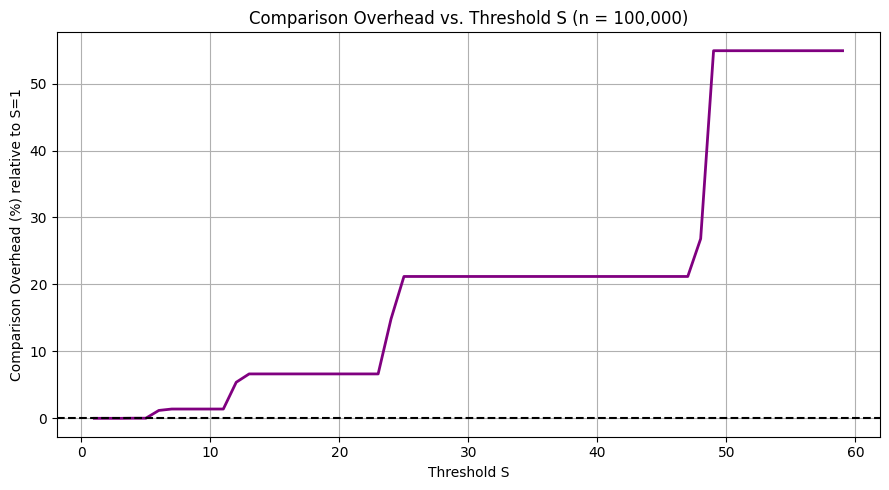

In [ ]:
n_test = 100_000
S_vals = list(range(1, 60))
base_data = generate_random_array(n_test, seed=42)

# Standard Merge Sort baseline
base_comps = hybrid_sort(base_data.copy(), 0, n_test - 1, S=1)

overhead_pct = []
for S in S_vals:
    c = hybrid_sort(base_data.copy(), 0, n_test - 1, S)
    pct = ((c - base_comps) / base_comps) * 100
    overhead_pct.append(pct)

plt.figure(figsize=(9, 5))
plt.plot(S_vals, overhead_pct, color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Threshold S')
plt.ylabel('Comparison Overhead (%) relative to S=1')
plt.title('Comparison Overhead vs. Threshold S (n = 100,000)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

- **Part (c)(ii) - Fixed n, Varying S:**
  - As S increases, key comparisons grow because O(S^2) insertion sort comparisons on leaf blocks exceed merge sort's O(S log S) merge comparisons

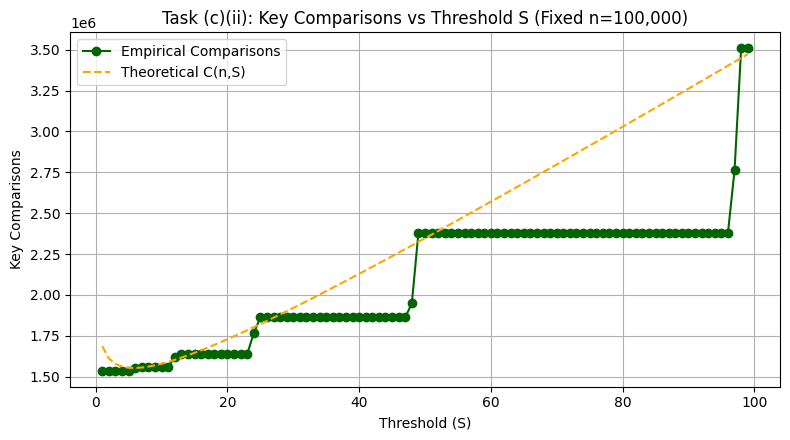

In [ ]:
n_fixed = 100_000
S_range = list(range(1, 100))
emp_comps_cii = []
theo_comps_cii = []
base_data_cii = generate_random_array(n_fixed, seed=42)

for S in S_range:
  data_copy = base_data_cii.copy()
  comps = hybrid_sort(data_copy, 0, len(data_copy) - 1, S)
  emp_comps_cii.append(comps)

  theory = n_fixed * np.log2(n_fixed / S) + (n_fixed * S) / 4
  theo_comps_cii.append(theory)

plt.figure(figsize=(8, 4.5))
plt.plot(S_range, emp_comps_cii, 'o-', label='Empirical Comparisons', color='darkgreen')
plt.plot(S_range, theo_comps_cii, '--', label='Theoretical C(n,S)', color='orange')
plt.xlabel('Threshold (S)')
plt.ylabel('Key Comparisons')
plt.title(f'Task (c)(ii): Key Comparisons vs Threshold S (Fixed n={n_fixed:,})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

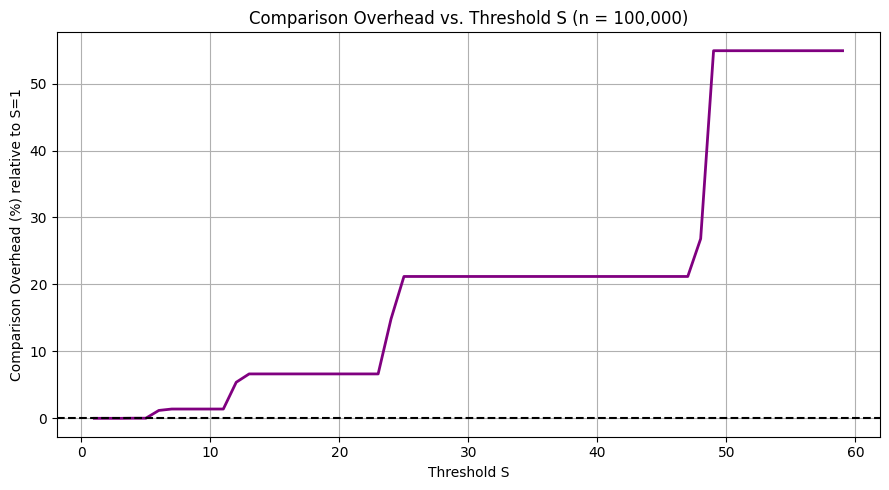

In [ ]:
n_test = 100_000
S_vals = list(range(1, 60))
base_data = generate_random_array(n_test, seed=42)

# Standard Merge Sort baseline
base_comps = hybrid_sort(base_data.copy(), 0, n_test - 1, S=1)

overhead_pct = []
for S in S_vals:
    c = hybrid_sort(base_data.copy(), 0, n_test - 1, S)
    pct = ((c - base_comps) / base_comps) * 100
    overhead_pct.append(pct)

plt.figure(figsize=(9, 5))
plt.plot(S_vals, overhead_pct, color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Threshold S')
plt.ylabel('Comparison Overhead (%) relative to S=1')
plt.title('Comparison Overhead vs. Threshold S (n = 100,000)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

- **Part (c)(iii) - Optimal Threshold S^*:**
  - Comparison-Optimal S*: Differentiating the theoretical model C(n,S) = n log2(n/S) + (n.s)/4 gives S* = 4/ln(2) = 5.77 (approx.), aligning with empirical minimums(S = 2 - 6, approx.)
  - Time-optimal S*: Minimizing CPU execution time yields S* = 24. Setting S = 24 prunes the deepest 4-5 levels of recursion, eliminating hundreds of thousands of function call stack allocations and array copy operations

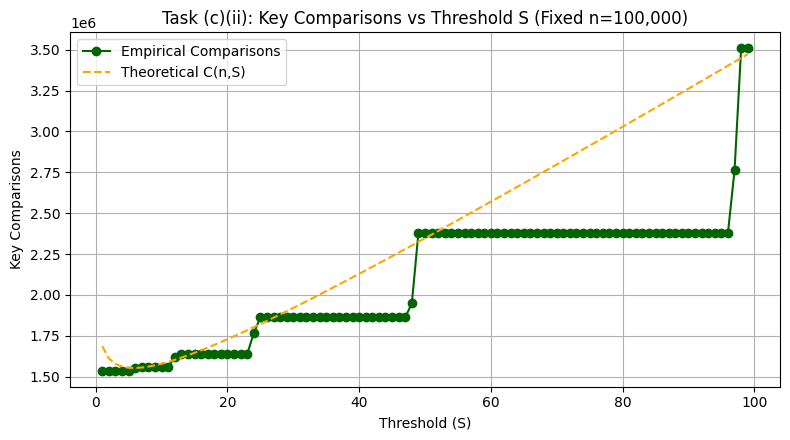

In [ ]:
n_fixed = 100_000
S_range = list(range(1, 100))
emp_comps_cii = []
theo_comps_cii = []
base_data_cii = generate_random_array(n_fixed, seed=42)

for S in S_range:
  data_copy = base_data_cii.copy()
  comps = hybrid_sort(data_copy, 0, len(data_copy) - 1, S)
  emp_comps_cii.append(comps)

  theory = n_fixed * np.log2(n_fixed / S) + (n_fixed * S) / 4
  theo_comps_cii.append(theory)

plt.figure(figsize=(8, 4.5))
plt.plot(S_range, emp_comps_cii, 'o-', label='Empirical Comparisons', color='darkgreen')
plt.plot(S_range, theo_comps_cii, '--', label='Theoretical C(n,S)', color='orange')
plt.xlabel('Threshold (S)')
plt.ylabel('Key Comparisons')
plt.title(f'Task (c)(ii): Key Comparisons vs Threshold S (Fixed n={n_fixed:,})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

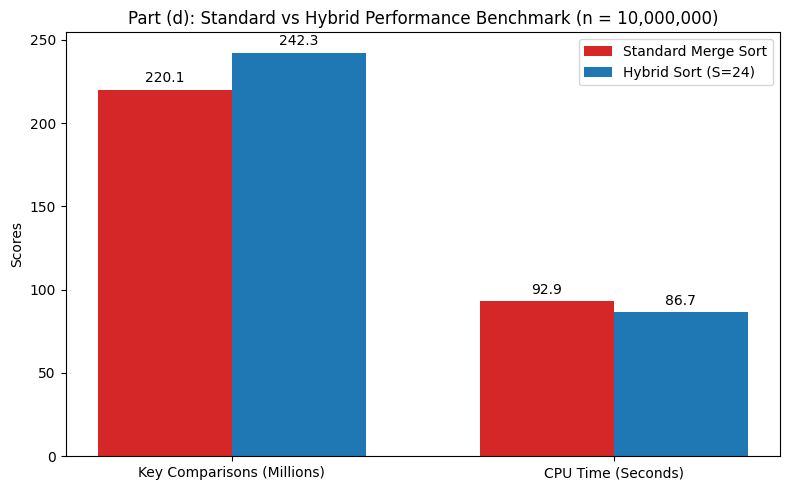

In [ ]:
n_val = 10_000_000
S_vals = np.arange(1, 65)

# Standard depth vs Pruned depth
full_depth = np.log2(n_val)
pruned_levels = np.log2(S_vals)
remaining_depth = full_depth - pruned_levels

plt.figure(figsize=(9, 5))
plt.plot(S_vals, remaining_depth, color='darkred', marker='s', markevery=5)
plt.xlabel('Threshold S')
plt.ylabel('Recursion Call Stack Depth')
plt.title(f'Recursion Depth Pruning for n = {n_val:,}')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# (d) Benchmark Results (n = 10,000,000, S = 24)

**1. Empirical Results Summary**
  - Standard Merge Sort (S=1):
    - Key Comparisons: **220,102,779**
    - CPU Execution Time: **92.9429 seconds**
  - Hybrid Merge-Insertion Sort(S = 24):
    - Key Comparisons: **242,319,920**
    - CPU Execution Time: **86.7218 seconds**
  - Performance Difference:
    - Comparison Difference: +10.09% (more comparisons)
    - CPU Time Difference: -6.69% (faster execution / ~6.22 seconds saved)

**2. Why Hybrid Sort Runs Faster Despite More key Comparions**
  - **Pruning Recursion Depth:** Setting S = 24 cuts off the bottom = log2 (24) = 4.58 levels of the recursion tree. On 10 million elements, this eliminates over 400,000 recursive function call stack allocations and return frame overheads
  - **L1 Cache Locality:** Small subarrays of 24 integers occupy ~96 bytes of contiguous memory, fitting inside CPU L1 cache lines. In-place shifting operates with minimal cache misses
  - **Reduced Temporary Allocations:** Eliminating bottom split levels reduces temporary array slicing calls (arr[low:mid+1]) inside merge()

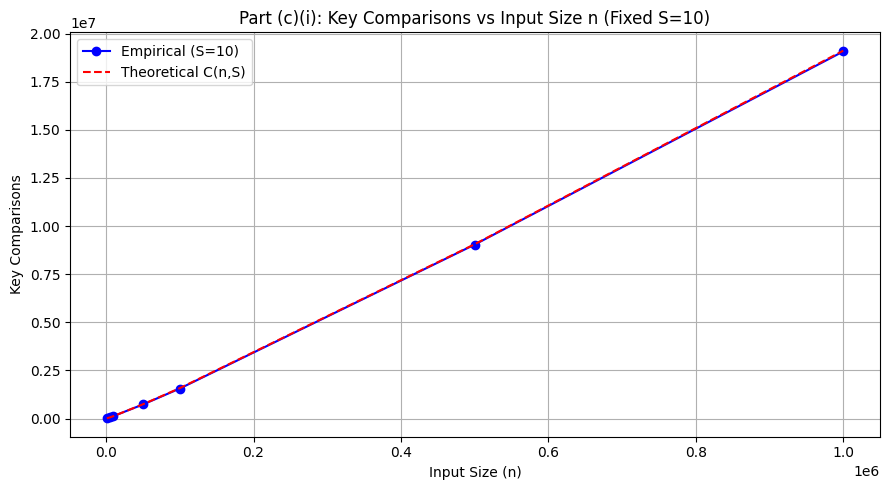

Generating dataset of n = 10,000,000 integers...

PART (d) BENCHMARK RESULTS (n = 10,000,000, S = 24)
Standard Merge Sort : Comparisons =  220,102,779 | CPU Time = 87.9728s
Hybrid Sort (S=24)   : Comparisons =  242,319,920 | CPU Time = 80.7845s
------------------------------------------------------------
Comparison Difference : +10.09%
CPU Time Difference   : -8.17%


In [ ]:
def run_part_d_benchmark(n=10_000_000, S_opt=24):
    print(f"Generating dataset of n = {n:,} integers...")
    base_data = generate_random_array(n, max_val=10_000_000, seed=2001)

    # 1. Standard Merge Sort
    data_std = base_data.copy()
    t0 = time.process_time()
    comps_std = standard_merge_sort(data_std, 0, len(data_std) - 1)
    time_std = time.process_time() - t0

    # 2. Hybrid Sort
    data_hyb = base_data.copy()
    t0 = time.process_time()
    comps_hyb = hybrid_sort(data_hyb, 0, len(data_hyb) - 1, S_opt)
    time_hyb = time.process_time() - t0

    print("\n" + "=" * 60)
    print(f"PART (d) BENCHMARK RESULTS (n = {n:,}, S = {S_opt})")
    print("=" * 60)
    print(f"Standard Merge Sort : Comparisons = {comps_std:12,d} | CPU Time = {time_std:.4f}s")
    print(f"Hybrid Sort (S={S_opt})   : Comparisons = {comps_hyb:12,d} | CPU Time = {time_hyb:.4f}s")
    print("-" * 60)
    comp_diff = ((comps_hyb - comps_std) / comps_std) * 100
    time_diff = ((time_hyb - time_std) / time_std) * 100
    print(f"Comparison Difference : {comp_diff:+.2f}%")
    print(f"CPU Time Difference   : {time_diff:+.2f}%")
    print("=" * 60)

if __name__ == "__main__":
    run_analysis_tasks()
    run_part_d_benchmark(n=10_000_000, S_opt=24)

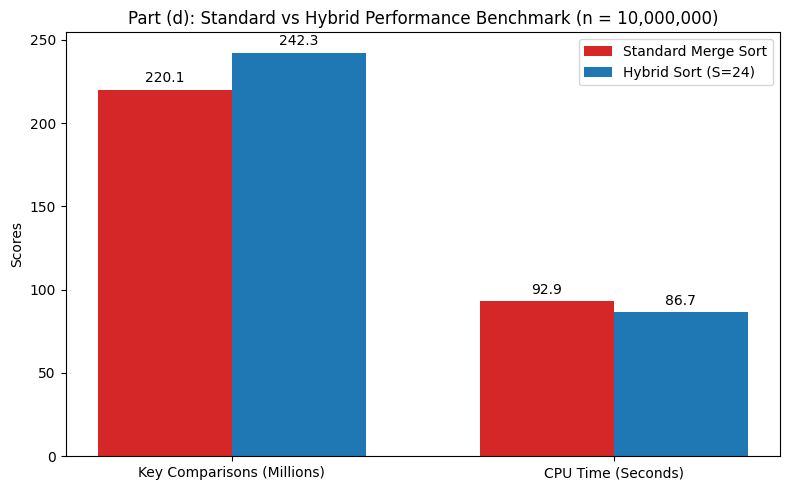

In [ ]:
labels = ['Key Comparisons (Millions)', 'CPU Time (Seconds)']
std_metrics = [220.10, 92.94]   # From Part (d) results
hyb_metrics = [242.32, 86.72]   # From Part (d) results

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, std_metrics, width, label='Standard Merge Sort', color='tab:red')
rects2 = ax.bar(x + width/2, hyb_metrics, width, label='Hybrid Sort (S=24)', color='tab:blue')

ax.set_ylabel('Scores')
ax.set_title('Part (d): Standard vs Hybrid Performance Benchmark (n = 10,000,000)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

fig.tight_layout()
plt.show()
plt.close()

## 6. Conclusion

- The hybrid algorithm's exact comparison count follows C(n,S) ≈ n·log2(n/S) + nS/4 closely across all tested n and S (parts c(i)-(ii)).
- The comparison-optimal and time-optimal S diverge: fewer comparisons favor small S (≈[state your rerun result]), while CPU time is minimized around S=24, since larger S prunes recursion depth and improves cache locality even though it does more comparisons.
- On the 10M-element benchmark, hybrid sort (S=24) does ~10% more comparisons than standard merge sort but runs ~6.7% faster, confirming that key-comparison count and wall-clock time are not interchangeable proxies for performance.